In [3]:
# =============================================================
# INSTALAÇÃO
# pip install mowl-borg mygene gensim scikit-learn umap-learn hdbscan matplotlib
# Requer Java JDK instalado (OWLAPI roda na JVM)
# =============================================================

import mowl
mowl.init_jvm("8g")  # inicia JVM — deve ser a primeira chamada, só pode ser feita uma vez

import os
import requests
import numpy as np
import pandas as pd
from pathlib import Path

# mOWL — módulos corretos conforme documentação
from mowl.datasets import PathDataset
from mowl.projection import OWL2VecStarProjector
from mowl.walking import DeepWalk, Node2Vec
from mowl.corpus import extract_and_save_axiom_corpus, extract_and_save_annotation_corpus

# Gensim
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

# Anotações GO
import mygene

# Clustering / visualização
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import hdbscan
import umap
import matplotlib.pyplot as plt

def gera_clusters_genes_com_mowl(data_name: str):
    # =============================================================
    # 1. CONFIGURAÇÃO
    # =============================================================
    DATA_DIR = Path("./go_data")
    DATA_DIR.mkdir(exist_ok=True)

    GO_OWL_FILE   = str(DATA_DIR / "go.owl")
    WALKS_FILE    = str(DATA_DIR / "walks.txt")
    CORPUS_FILE   = str(DATA_DIR / "corpus.txt")

    mRNA_data = pd.read_csv(f"data/deepkegg/{data_name}_data/mRNA_data.csv")
    genes = mRNA_data.columns[1:].tolist()  # Ignora a coluna 'Case_ID'

    # =============================================================
    # 2. DOWNLOAD DA ONTOLOGIA GO
    # =============================================================
    def download_go_owl(dest: str) -> None:
        if os.path.exists(dest):
            print(f"go.owl já existe em {dest}")
            return
        url = "http://purl.obolibrary.org/obo/go.owl"
        print("Baixando go.owl (~200MB)...")
        with requests.get(url, stream=True) as r:
            r.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in r.iter_content(chunk_size=16384):
                    f.write(chunk)
        print("Download concluído.")

    download_go_owl(GO_OWL_FILE)

    # =============================================================
    # 3. BUSCAR TERMOS GO POR GENE (mygene.info)
    # =============================================================
    def fetch_go_terms(gene_list: list) -> dict:
        mg = mygene.MyGeneInfo()
        hits = mg.querymany(
            gene_list, scopes="symbol", fields="go",
            species="human", returnall=False, verbose=False
        )
        gene_go_map = {}
        for hit in hits:
            symbol = hit.get("query", "")
            entries = hit.get("go", {})
            uris = []
            for ns in ("BP", "MF", "CC"):
                items = entries.get(ns, [])
                if isinstance(items, dict):   # mygene retorna dict quando há só 1 termo
                    items = [items]
                for item in items:
                    go_id = item.get("id", "")
                    if go_id:
                        # Formato URI que mOWL usa: http://purl.obolibrary.org/obo/GO_XXXXXXX
                        uri = f"http://purl.obolibrary.org/obo/{go_id.replace(':', '_')}"
                        uris.append(uri)
            gene_go_map[symbol] = list(set(uris))
        return gene_go_map

    print("Buscando anotações GO...")
    gene_go_map = fetch_go_terms(genes)
    annotated   = {g: t for g, t in gene_go_map.items() if t}
    print(f"Genes anotados: {len(annotated)}/{len(genes)}")

    # =============================================================
    # 4. CARREGAR ONTOLOGIA COM PathDataset
    # =============================================================
    dataset = PathDataset(GO_OWL_FILE)

    # =============================================================
    # 5A. PROJEÇÃO OWL → GRAFO  (OWL2VecStarProjector)
    # =============================================================
    # OWL2VecStarProjector converte axiomas OWL em arestas (edgelist)
    projector = OWL2VecStarProjector(
        bidirectional_taxonomy=True,   # gera arestas SubClass E SuperClass
        only_taxonomy=False,           # inclui relações além de is_a (part_of, etc.)
        include_literals=True          # inclui anotações textuais no grafo
    )

    print("Projetando ontologia GO em grafo...")
    edges = projector.project(dataset.ontology)   # retorna lista de tuplas (src, rel, dst)

    # =============================================================
    # 5B. RANDOM WALKS NO GRAFO  (Node2Vec)
    # =============================================================
    # Node2Vec(num_walks, walk_length, p, q, outfile, workers)
    walker = Node2Vec(
        num_walks=20,
        walk_length=10,
        p=1.0,          # parâmetro de retorno (BFS-like quando p<1)
        q=1.0,          # parâmetro de exploração (DFS-like quando q<1)
        outfile=WALKS_FILE,
        workers=os.cpu_count()
    )

    print("Gerando random walks...")
    walker.walk(edges)   # salva os walks em WALKS_FILE

    # =============================================================
    # 5C. CORPUS DE ANOTAÇÕES (labels, definições dos termos GO)
    # =============================================================
    # OWL2Vec* combina walks estruturais + corpus textual de anotações
    print("Extraindo corpus de anotações...")
    extract_and_save_axiom_corpus(dataset.ontology, CORPUS_FILE)
    extract_and_save_annotation_corpus(dataset.ontology, CORPUS_FILE, mode="a")

    # =============================================================
    # 5D. TREINAR WORD2VEC NOS DOIS CORPORA COMBINADOS
    # =============================================================
    # Combina o arquivo de walks + corpus de anotações em um único iterável
    class CombinedSentences:
        """Itera sobre walks (estrutural) e corpus de anotações (textual)."""
        def __init__(self, walks_file: str, corpus_file: str):
            self.files = [walks_file, corpus_file]

        def __iter__(self):
            for fpath in self.files:
                for line in open(fpath, encoding="utf-8"):
                    yield line.strip().split()

    print("Treinando Word2Vec (OWL2Vec*)...")
    sentences = CombinedSentences(WALKS_FILE, CORPUS_FILE)

    w2v_model = Word2Vec(
        sentences,
        vector_size=128,
        window=5,
        min_count=1,
        workers=os.cpu_count(),
        epochs=50, # para teste rápido, aumente para 30-50 para melhor qualidade
        sg=1            # skip-gram (recomendado para ontologias esparsas)
    )
    wv = w2v_model.wv
    print(f"Vocabulário treinado: {len(wv)} entidades/tokens")

    # =============================================================
    # 6. GERAR EMBEDDING POR GENE
    #    Cada gene = média dos embeddings dos seus termos GO
    # =============================================================
    def gene_embedding(go_uris: list, wv) -> np.ndarray | None:
        vecs = [wv[uri] for uri in go_uris if uri in wv]
        return np.mean(vecs, axis=0) if vecs else None

    print("Calculando embeddings por gene...")
    gene_names, gene_vectors = [], []

    for gene, uris in annotated.items():
        vec = gene_embedding(uris, wv)
        if vec is not None:
            gene_names.append(gene)
            gene_vectors.append(vec)
    
    X  = np.array(gene_vectors)
    pd.DataFrame(X, index=gene_names).to_csv(f"data/output/{data_name}_embeddings_mowl.csv")
    Xs = StandardScaler().fit_transform(X)
    print(f"Genes com embedding válido: {len(gene_names)}")

    # =============================================================
    # 7. CLUSTERIZAÇÃO
    # =============================================================

    # --- KMeans com seleção de K por Silhouette ---
    def select_best_k(X: np.ndarray, k_range=range(2, 20)):
        best_k, best_score, best_model = 2, -1, None
        scores = []
        for k in k_range:
            km     = KMeans(n_clusters=k, n_init="auto")
            labels = km.fit_predict(X)
            score  = silhouette_score(X, labels)
            scores.append(score)
            if score > best_score:
                best_score, best_k, best_model = score, k, km
        print(f"Melhor K={best_k} | Silhouette={best_score:.4f}")
        return best_model, best_k, scores

    km_model, best_k, sil_scores = select_best_k(Xs)
    kmeans_labels = km_model.labels_

    # --- HDBSCAN (clusters automáticos, trata ruído) ---
    hdb = hdbscan.HDBSCAN(
        min_samples=3,
        metric="euclidean"
    )
    hdb_labels = hdb.fit_predict(Xs)
    n_hdb  = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    noise  = (hdb_labels == -1).sum()
    print(f"HDBSCAN: {n_hdb} clusters | {noise} genes sem cluster")

    # =============================================================
    # 8. REDUÇÃO DIMENSIONAL E VISUALIZAÇÃO
    # =============================================================
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    X_2d    = reducer.fit_transform(Xs)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, labels, title in zip(
        axes,
        [kmeans_labels, hdb_labels],
        [f"KMeans  k={best_k}", f"HDBSCAN  {n_hdb} clusters"]
    ):
        sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab20", s=18, alpha=0.85)
        plt.colorbar(sc, ax=ax, shrink=0.8)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

    pd.DataFrame(X_2d, index=gene_names, columns=["UMAP1", "UMAP2"]).to_csv(f"data/output/{data_name}_umap_mowl.csv")

    plt.suptitle("Clusterização de Genes — mOWL + OWL2Vec* + GO", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"data/output/clusters_{data_name}.png", dpi=150)
    plt.show()


    # =============================================================
    # 9. EXPORTAR RESULTADOS
    # =============================================================
    df = pd.DataFrame({
        "gene":            gene_names,
        "cluster_kmeans":  kmeans_labels,
        "cluster_hdbscan": hdb_labels,
    })
    df.to_csv(f"data/output/genes_clustered_{data_name}.csv", index=False)
    print("\nTop clusters KMeans:")
    print(df.groupby("cluster_kmeans")["gene"].count().sort_values(ascending=False).head(10))


  0%|          | 0/4 [00:00<?, ?it/s]WARNING:biothings.client:Input sequence provided is already in string format. No operation performed


Generating clusters for BLCA
go.owl já existe em go_data\go.owl
Buscando anotações GO...


INFO:httpx:HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"


Genes anotados: 997/1000
Projetando ontologia GO em grafo...
Gerando random walks...


INFO:root:Generating axioms corpus


...

INFO:root:Generating annotation corpus
INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 85728 words, keeping 13170 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 169575 words, keeping 19196 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 251725 words, keeping 25037 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 337272 words, keeping 28894 word types


Treinando Word2Vec (OWL2Vec*)...


INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 421738 words, keeping 30821 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #60000, processed 508534 words, keeping 32344 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #70000, processed 593557 words, keeping 33761 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #80000, processed 677824 words, keeping 35253 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #90000, processed 763275 words, keeping 36400 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #100000, processed 845705 words, keeping 37927 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #110000, processed 928535 words, keeping 38883 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #120000, processed 1012484 words, keeping 40002 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #130000, processed 1095642 words, keeping 41166 word types
INFO:gensim.models.word2vec:PRO

Vocabulário treinado: 462024 entidades/tokens
Calculando embeddings por gene...
Genes com embedding válido: 997
Melhor K=18 | Silhouette=0.1433
HDBSCAN: 16 clusters | 752 genes sem cluster


c:\Users\grkremer\miniconda3\envs\mowl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


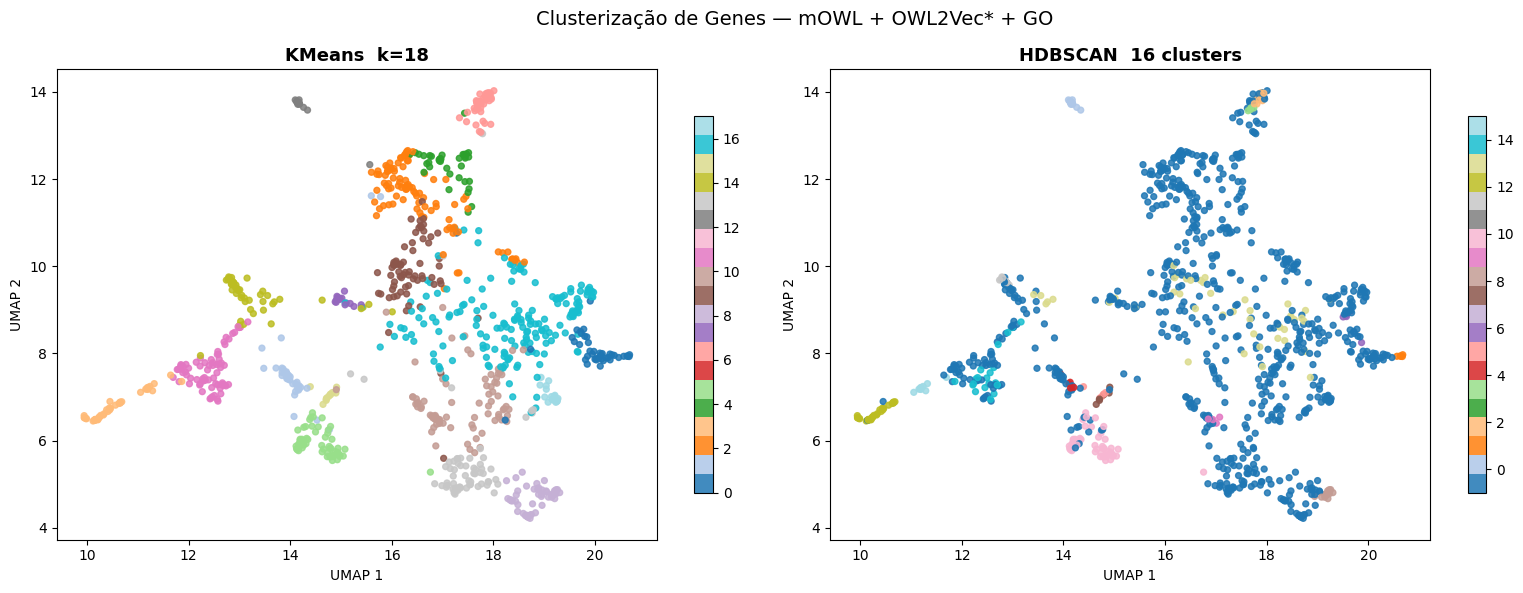

 25%|██▌       | 1/4 [54:17<2:42:53, 3257.68s/it]


Top clusters KMeans:
cluster_kmeans
16    182
2      97
10     82
11     74
9      69
13     66
5      57
8      52
14     51
6      44
Name: gene, dtype: int64
Generating clusters for BRCA


go.owl já existe em go_data\go.owl
Buscando anotações GO...


INFO:httpx:HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"


Genes anotados: 996/1000
Projetando ontologia GO em grafo...
Gerando random walks...


...

INFO:root:Generating annotation corpus
INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 87298 words, keeping 10608 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 171561 words, keeping 14868 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 255841 words, keeping 18020 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 340860 words, keeping 20662 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 424118 words, keeping 23298 word types


Treinando Word2Vec (OWL2Vec*)...


INFO:gensim.models.word2vec:PROGRESS: at sentence #60000, processed 507414 words, keeping 25262 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #70000, processed 591806 words, keeping 26713 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #80000, processed 673010 words, keeping 29072 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #90000, processed 755502 words, keeping 30799 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #100000, processed 840170 words, keeping 33124 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #110000, processed 923066 words, keeping 35041 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #120000, processed 1005725 words, keeping 37055 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #130000, processed 1090525 words, keeping 38731 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #140000, processed 1172881 words, keeping 40267 word types
INFO:gensim.models.word2vec:P

Vocabulário treinado: 462024 entidades/tokens
Calculando embeddings por gene...
Genes com embedding válido: 996
Melhor K=9 | Silhouette=0.1247
HDBSCAN: 18 clusters | 808 genes sem cluster


c:\Users\grkremer\miniconda3\envs\mowl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


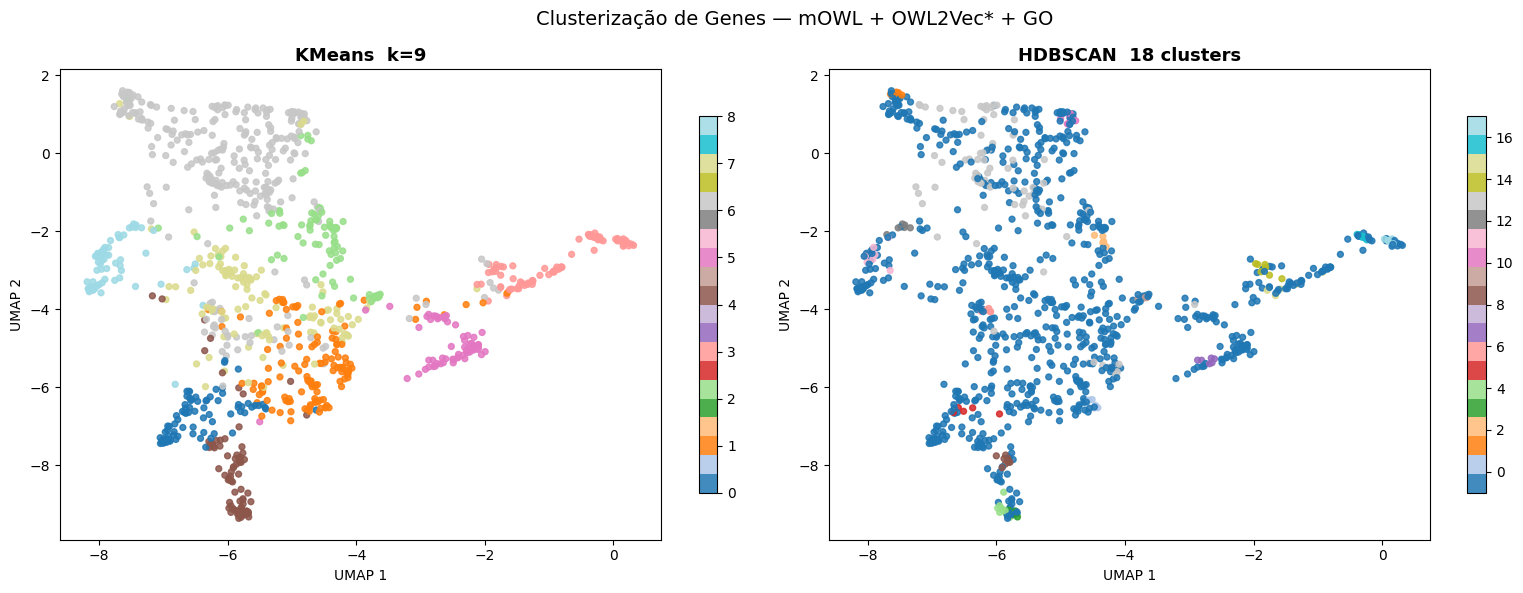

 50%|█████     | 2/4 [1:46:18<1:45:54, 3177.18s/it]


Top clusters KMeans:
cluster_kmeans
6    287
1    129
7    117
2     90
3     84
4     81
0     79
8     67
5     62
Name: gene, dtype: int64
Generating clusters for LIHC


go.owl já existe em go_data\go.owl
Buscando anotações GO...


INFO:httpx:HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"


Genes anotados: 998/1000
Projetando ontologia GO em grafo...
Gerando random walks...


...

INFO:root:Generating annotation corpus
INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 87796 words, keeping 7514 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 170438 words, keeping 12926 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 253016 words, keeping 16926 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 338881 words, keeping 20278 word types


Treinando Word2Vec (OWL2Vec*)...


INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 423085 words, keeping 24590 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #60000, processed 502968 words, keeping 27304 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #70000, processed 586479 words, keeping 30025 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #80000, processed 673375 words, keeping 33919 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #90000, processed 758641 words, keeping 36476 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #100000, processed 840584 words, keeping 39283 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #110000, processed 926803 words, keeping 40574 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #120000, processed 1011841 words, keeping 42164 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #130000, processed 1096011 words, keeping 43430 word types
INFO:gensim.models.word2vec:PRO

Vocabulário treinado: 462024 entidades/tokens
Calculando embeddings por gene...
Genes com embedding válido: 998
Melhor K=18 | Silhouette=0.1442
HDBSCAN: 18 clusters | 781 genes sem cluster


c:\Users\grkremer\miniconda3\envs\mowl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


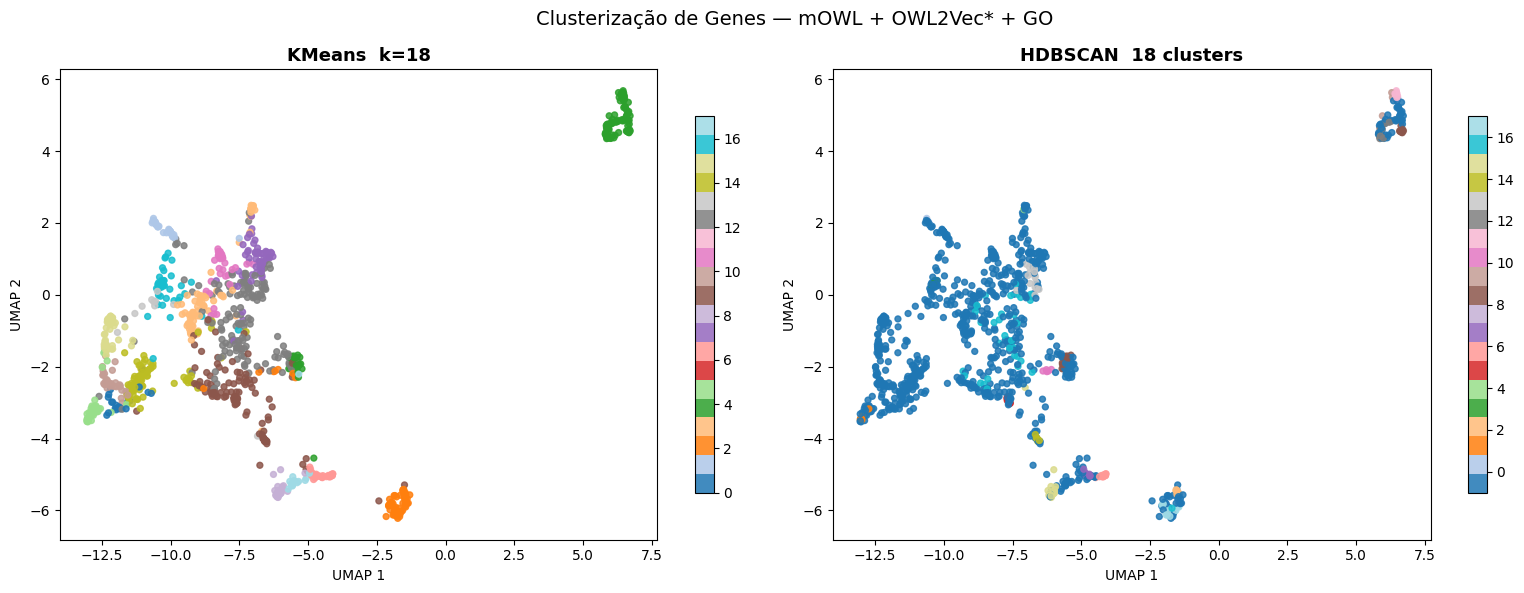

 75%|███████▌  | 3/4 [2:38:40<52:40, 3160.88s/it]  WARNING:biothings.client:Input sequence provided is already in string format. No operation performed



Top clusters KMeans:
cluster_kmeans
12    153
9     117
4     112
3      78
14     78
2      66
7      56
15     44
16     44
5      38
Name: gene, dtype: int64
Generating clusters for PRAD
go.owl já existe em go_data\go.owl
Buscando anotações GO...


INFO:httpx:HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"


Genes anotados: 1497/1500
Projetando ontologia GO em grafo...
Gerando random walks...


INFO:root:Generating axioms corpus


...

INFO:root:Generating annotation corpus
INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 86666 words, keeping 9220 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 170656 words, keeping 14074 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 254283 words, keeping 18036 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 339341 words, keeping 21715 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 420574 words, keeping 25102 word types


Treinando Word2Vec (OWL2Vec*)...


INFO:gensim.models.word2vec:PROGRESS: at sentence #60000, processed 503605 words, keeping 28625 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #70000, processed 587287 words, keeping 31824 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #80000, processed 672671 words, keeping 33884 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #90000, processed 757173 words, keeping 37089 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #100000, processed 843640 words, keeping 38662 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #110000, processed 928481 words, keeping 40588 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #120000, processed 1012291 words, keeping 41366 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #130000, processed 1096350 words, keeping 42348 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #140000, processed 1179977 words, keeping 43515 word types
INFO:gensim.models.word2vec:P

Vocabulário treinado: 462024 entidades/tokens
Calculando embeddings por gene...
Genes com embedding válido: 1497
Melhor K=15 | Silhouette=0.1160
HDBSCAN: 30 clusters | 1144 genes sem cluster


c:\Users\grkremer\miniconda3\envs\mowl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


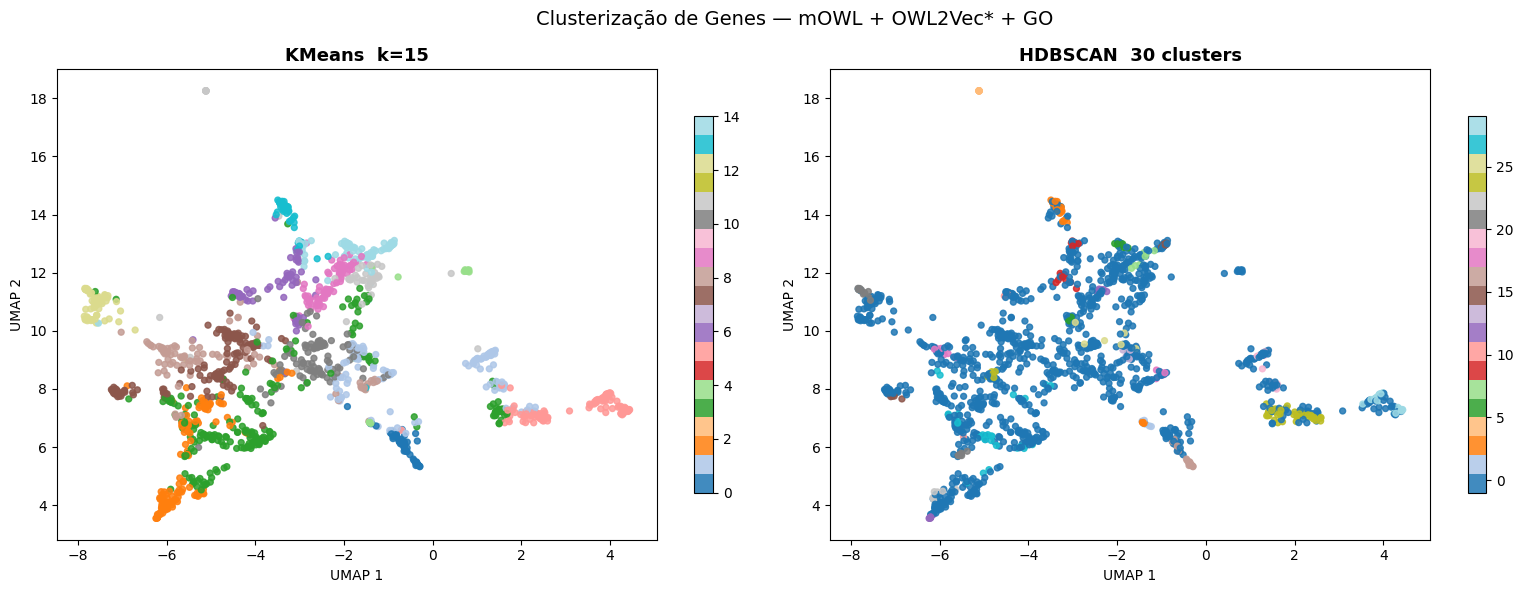

100%|██████████| 4/4 [3:31:24<00:00, 3171.23s/it]


Top clusters KMeans:
cluster_kmeans
3     239
7     160
2     138
1     137
5     110
10    108
8     105
14     80
9      80
12     75
Name: gene, dtype: int64


In [4]:
from tqdm import tqdm
for i in tqdm(["BLCA", "BRCA", "LIHC", "PRAD"]):
    print("Generating clusters for", i)
    gera_clusters_genes_com_mowl(data_name = i)

go.owl já existe em go_data\go.owl
Buscando anotações GO...


INFO:httpx:HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"


Genes anotados: 997/1000
Projetando ontologia GO em grafo...
Gerando random walks...


INFO:root:Generating axioms corpus


Extraindo corpus de anotações...


INFO:root:Generating annotation corpus
INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 86023 words, keeping 9088 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 169072 words, keeping 12988 word types


Treinando Word2Vec (OWL2Vec*)...


INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 252173 words, keeping 16934 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 337143 words, keeping 20693 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 420692 words, keeping 23483 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #60000, processed 503277 words, keeping 27054 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #70000, processed 585941 words, keeping 28973 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #80000, processed 670794 words, keeping 31214 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #90000, processed 757368 words, keeping 33365 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #100000, processed 841318 words, keeping 35837 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #110000, processed 925294 words, keeping 37033 word types
INFO:gensim.models.word2vec:PROGRES

Vocabulário treinado: 462024 entidades/tokens
Calculando embeddings por gene...
Genes com embedding válido: 997
Melhor K=4 | Silhouette=0.1609
HDBSCAN: 17 clusters | 715 genes sem cluster


c:\Users\grkremer\miniconda3\envs\mowl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


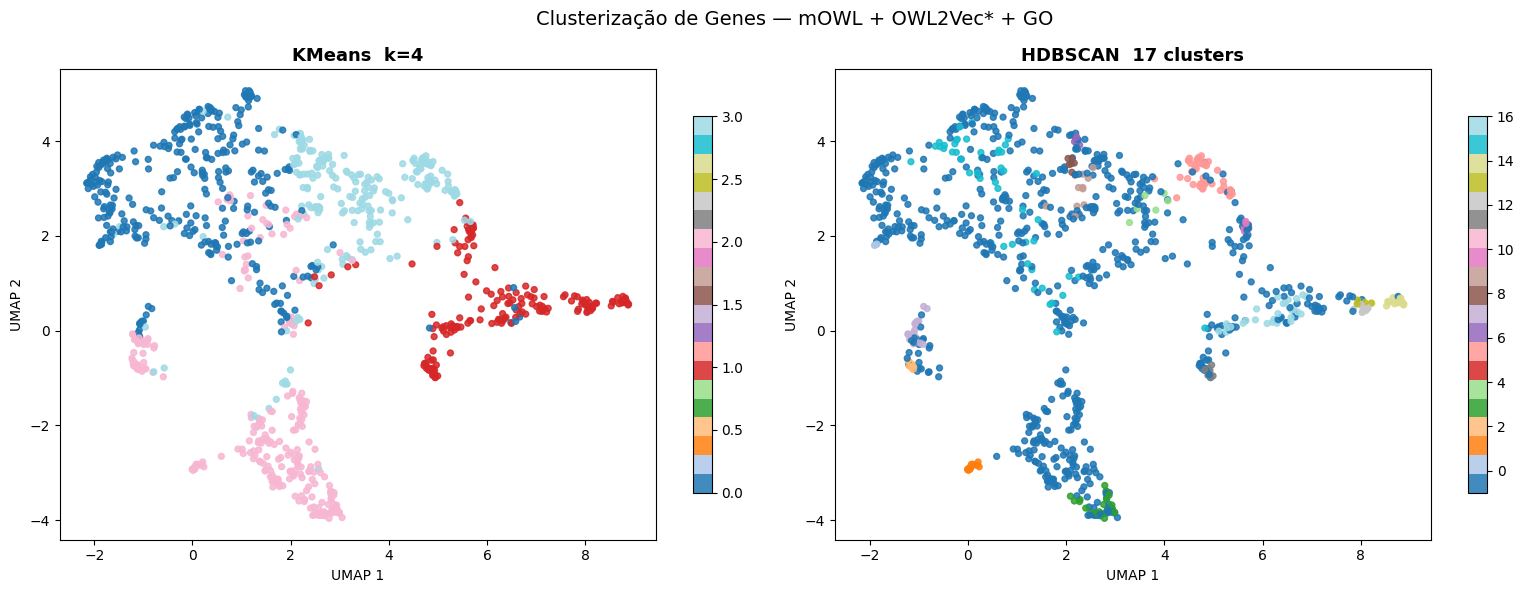


Top clusters KMeans:
cluster_kmeans
0    328
2    257
3    227
1    185
Name: gene, dtype: int64


In [ ]:
mRNA_data = pd.read_csv(f'data/deepkegg/BLCA_data/mRNA_data.csv')
out_file = f"gene_clusters_mowl_{i}"

# =============================================================
# 1. CONFIGURAÇÃO
# =============================================================
DATA_DIR = Path("./go_data")
DATA_DIR.mkdir(exist_ok=True)

GO_OWL_FILE   = str(DATA_DIR / "go.owl")
WALKS_FILE    = str(DATA_DIR / "walks.txt")
CORPUS_FILE   = str(DATA_DIR / "corpus.txt")

mRNA_data = mRNA_data.copy()
genes = mRNA_data.columns[1:].tolist()  # Ignora a coluna 'Case_ID'

# =============================================================
# 2. DOWNLOAD DA ONTOLOGIA GO
# =============================================================
def download_go_owl(dest: str) -> None:
    if os.path.exists(dest):
        print(f"go.owl já existe em {dest}")
        return
    url = "http://purl.obolibrary.org/obo/go.owl"
    print("Baixando go.owl (~200MB)...")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=16384):
                f.write(chunk)
    print("Download concluído.")

download_go_owl(GO_OWL_FILE)

# =============================================================
# 3. BUSCAR TERMOS GO POR GENE (mygene.info)
# =============================================================
def fetch_go_terms(gene_list: list) -> dict:
    mg = mygene.MyGeneInfo()
    hits = mg.querymany(
        gene_list, scopes="symbol", fields="go",
        species="human", returnall=False, verbose=False
    )
    gene_go_map = {}
    for hit in hits:
        symbol = hit.get("query", "")
        entries = hit.get("go", {})
        uris = []
        for ns in ("BP", "MF", "CC"):
            items = entries.get(ns, [])
            if isinstance(items, dict):   # mygene retorna dict quando há só 1 termo
                items = [items]
            for item in items:
                go_id = item.get("id", "")
                if go_id:
                    # Formato URI que mOWL usa: http://purl.obolibrary.org/obo/GO_XXXXXXX
                    uri = f"http://purl.obolibrary.org/obo/{go_id.replace(':', '_')}"
                    uris.append(uri)
        gene_go_map[symbol] = list(set(uris))
    return gene_go_map

print("Buscando anotações GO...")
gene_go_map = fetch_go_terms(genes)
annotated   = {g: t for g, t in gene_go_map.items() if t}
print(f"Genes anotados: {len(annotated)}/{len(genes)}")

# =============================================================
# 4. CARREGAR ONTOLOGIA COM PathDataset
# =============================================================
dataset = PathDataset(GO_OWL_FILE)

# =============================================================
# 5A. PROJEÇÃO OWL → GRAFO  (OWL2VecStarProjector)
# =============================================================
# OWL2VecStarProjector converte axiomas OWL em arestas (edgelist)
projector = OWL2VecStarProjector(
    bidirectional_taxonomy=True,   # gera arestas SubClass E SuperClass
    only_taxonomy=False,           # inclui relações além de is_a (part_of, etc.)
    include_literals=True          # inclui anotações textuais no grafo
)

print("Projetando ontologia GO em grafo...")
edges = projector.project(dataset.ontology)   # retorna lista de tuplas (src, rel, dst)

# =============================================================
# 5B. RANDOM WALKS NO GRAFO  (Node2Vec)
# =============================================================
# Node2Vec(num_walks, walk_length, p, q, outfile, workers)
walker = Node2Vec(
    num_walks=20,
    walk_length=10,
    p=1.0,          # parâmetro de retorno (BFS-like quando p<1)
    q=1.0,          # parâmetro de exploração (DFS-like quando q<1)
    outfile=WALKS_FILE,
    workers=os.cpu_count()
)

print("Gerando random walks...")
walker.walk(edges)   # salva os walks em WALKS_FILE

# =============================================================
# 5C. CORPUS DE ANOTAÇÕES (labels, definições dos termos GO)
# =============================================================
# OWL2Vec* combina walks estruturais + corpus textual de anotações
print("Extraindo corpus de anotações...")
extract_and_save_axiom_corpus(dataset.ontology, CORPUS_FILE)
extract_and_save_annotation_corpus(dataset.ontology, CORPUS_FILE, mode="a")

# =============================================================
# 5D. TREINAR WORD2VEC NOS DOIS CORPORA COMBINADOS
# =============================================================
# Combina o arquivo de walks + corpus de anotações em um único iterável
class CombinedSentences:
    """Itera sobre walks (estrutural) e corpus de anotações (textual)."""
    def __init__(self, walks_file: str, corpus_file: str):
        self.files = [walks_file, corpus_file]

    def __iter__(self):
        for fpath in self.files:
            for line in open(fpath, encoding="utf-8"):
                yield line.strip().split()

print("Treinando Word2Vec (OWL2Vec*)...")
sentences = CombinedSentences(WALKS_FILE, CORPUS_FILE)

w2v_model = Word2Vec(
    sentences,
    vector_size=128,
    window=5,
    min_count=1,
    workers=os.cpu_count(),
    epochs=2,   # AUMENTAR para 30-50 para melhor qualidade
    sg=1        # skip-gram (recomendado para ontologias esparsas)
)
wv = w2v_model.wv
print(f"Vocabulário treinado: {len(wv)} entidades/tokens")

# =============================================================
# 6. GERAR EMBEDDING POR GENE
#    Cada gene = média dos embeddings dos seus termos GO
# =============================================================
def gene_embedding(go_uris: list, wv) -> np.ndarray | None:
    vecs = [wv[uri] for uri in go_uris if uri in wv]
    return np.mean(vecs, axis=0) if vecs else None

print("Calculando embeddings por gene...")
gene_names, gene_vectors = [], []

for gene, uris in annotated.items():
    vec = gene_embedding(uris, wv)
    if vec is not None:
        gene_names.append(gene)
        gene_vectors.append(vec)


X  = np.array(gene_vectors)
Xs = StandardScaler().fit_transform(X)
print(f"Genes com embedding válido: {len(gene_names)}")



# =============================================================
# 7. CLUSTERIZAÇÃO
# =============================================================

# --- KMeans com seleção de K por Silhouette ---
def select_best_k(X: np.ndarray, k_range=range(2, 20)):
    best_k, best_score, best_model = 2, -1, None
    scores = []
    for k in k_range:
        km     = KMeans(n_clusters=k, n_init="auto")
        labels = km.fit_predict(X)
        score  = silhouette_score(X, labels)
        scores.append(score)
        if score > best_score:
            best_score, best_k, best_model = score, k, km
    print(f"Melhor K={best_k} | Silhouette={best_score:.4f}")
    return best_model, best_k, scores

km_model, best_k, sil_scores = select_best_k(Xs)
kmeans_labels = km_model.labels_

# --- HDBSCAN (clusters automáticos, trata ruído) ---
hdb = hdbscan.HDBSCAN(
    min_samples=3,
    metric="euclidean"
)
hdb_labels = hdb.fit_predict(Xs)
n_hdb  = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
noise  = (hdb_labels == -1).sum()
print(f"HDBSCAN: {n_hdb} clusters | {noise} genes sem cluster")


# =============================================================
# 8. REDUÇÃO DIMENSIONAL E VISUALIZAÇÃO
# =============================================================
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_2d    = reducer.fit_transform(Xs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, labels, title in zip(
    axes,
    [kmeans_labels, hdb_labels],
    [f"KMeans  k={best_k}", f"HDBSCAN  {n_hdb} clusters"]
):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab20", s=18, alpha=0.85)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

plt.suptitle("Clusterização de Genes — mOWL + OWL2Vec* + GO", fontsize=14)
plt.tight_layout()
plt.savefig(out_file+".png", dpi=150)
plt.show()


# =============================================================
# 9. EXPORTAR RESULTADOS
# =============================================================
df = pd.DataFrame({
    "gene":            gene_names,
    "cluster_kmeans":  kmeans_labels,
    "cluster_hdbscan": hdb_labels,
})
df.to_csv(out_file+".csv", index=False)
print("\nTop clusters KMeans:")
print(df.groupby("cluster_kmeans")["gene"].count().sort_values(ascending=False).head(10))

C:\Users\grkremer\AppData\Local\Temp\ipykernel_13208\1845776466.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


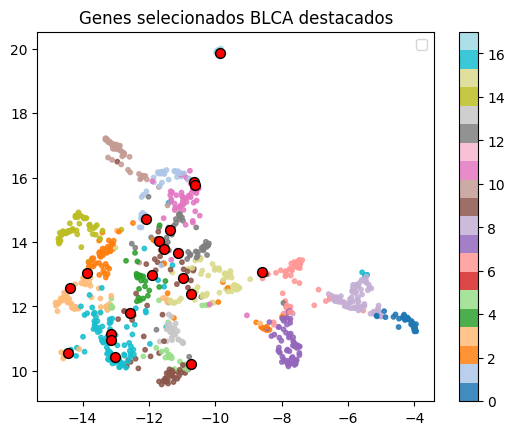

ValueError: 'c' argument has 998 elements, which is inconsistent with 'x' and 'y' with size 997.

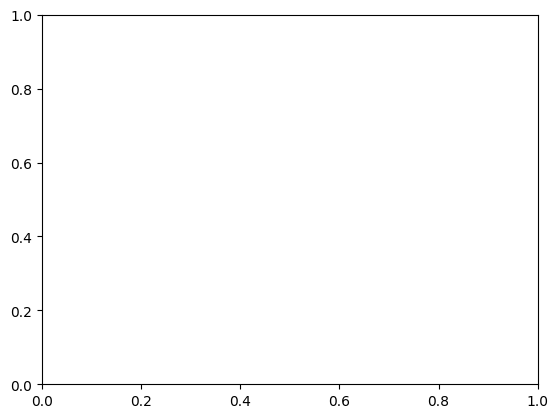

In [ ]:
def get_pos_by_gene(gene: str, gene_names: list[str]) -> int | None:
    try:
        return gene_names.index(gene)
    except ValueError:
        return None


def plot_selected_genes(gene_names: list[str], labels: np.ndarray, selected_genes: list[str], color = "red"):
    positions = [get_pos_by_gene(g, gene_names) for g in selected_genes]
    
    for pos in positions:
        if pos is not None:
            plt.scatter(X_2d[pos, 0], X_2d[pos, 1], color=color, edgecolor="black", s=50)
    plt.legend()

def plot_all_genes(gene_names: list[str], labels: np.ndarray):
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab20", s=10, alpha=0.85)
    plt.colorbar()
    plt.title("Todos os genes")

def plot_genes_and_selected(gene_names, kmeans_labels, selected_genes, title, color="red"):
    plot_all_genes(gene_names, kmeans_labels)
    plot_selected_genes(gene_names, kmeans_labels, selected_genes, color=color)
    plt.title("Genes selecionados " + title + " destacados")
    plt.show()


gene_names = pd.read_csv("gene_clusters_mowl_BLCA.csv")["gene"].tolist()
kmeans_labels = pd.read_csv("gene_clusters_mowl_BLCA.csv")["cluster_kmeans"].tolist()
selected_article_BLCA = ['ADCY3', 'PRKAA2', 'ALDH3A1', 'ADCY9', 'CALML3', 'COL1A1', 'CHEK1', 'PLA2G4E', 'COL6A3', 'FBP1', 'FN1', 'CD3D', 'MIOX', 'WNT3A', 'STXBP1', 'FGF22', 'KITLG', 'IRS1', 'PIK3CG', 'NDUFS8']
plot_genes_and_selected(gene_names, kmeans_labels, selected_article_BLCA, title="BLCA", color="red")

gene_names = pd.read_csv("gene_clusters_mowl_LIHC.csv")["gene"].tolist()
kmeans_labels = pd.read_csv("gene_clusters_mowl_LIHC.csv")["cluster_kmeans"].tolist()
selected_article_LICH = ['CYP1A2', 'TAT', 'ACAT2', 'ELK1', 'CXCL12', 'CPT1B', 'CYP2E1', 'EGF', 'CTNNA3', 'PIK3R2', 'IFNG', 'INPP4A', 'ACACA', 'SEC61A2', 'CD8A', 'ATP2A3', 'EFNA3', 'CDC25B', 'IPMK', 'PRF1']
plot_genes_and_selected(gene_names, kmeans_labels, selected_article_LICH, title="LIHC", color="blue")